In [92]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [93]:
temp = pd.read_csv("annual-temperature-anomalies.csv")
temp

,Entity,Code,Year,Temperature anomaly
0,Afghanistan,AFG,1940,-1.202316
1,Afghanistan,AFG,1941,0.794745
2,Afghanistan,AFG,1942,0.355437
3,Afghanistan,AFG,1943,-1.005242
4,Afghanistan,AFG,1944,-0.386346
...,...,...,...,...
18100,Zimbabwe,ZWE,2020,0.229293
18101,Zimbabwe,ZWE,2021,0.016838
18102,Zimbabwe,ZWE,2022,0.035659
18103,Zimbabwe,ZWE,2023,0.792851


In [94]:
temp[temp.Code == "USA"]

,Entity,Code,Year,Temperature anomaly
17170,United States,USA,1940,-1.546897
17171,United States,USA,1941,-1.575821
17172,United States,USA,1942,-1.743081
17173,United States,USA,1943,-1.213298
17174,United States,USA,1944,-1.101448
...,...,...,...,...
17250,United States,USA,2020,0.681033
17251,United States,USA,2021,0.627022
17252,United States,USA,2022,0.275057
17253,United States,USA,2023,0.761560


In [95]:
{
"2020": temp[temp.Year == 2020]["Temperature anomaly"].mean(),
"2010": temp[temp.Year == 2010]["Temperature anomaly"].mean(),
"2000": temp[temp.Year == 2000]["Temperature anomaly"].mean(),
"1990": temp[temp.Year == 1990]["Temperature anomaly"].mean(),
"1980": temp[temp.Year == 1980]["Temperature anomaly"].mean()
}


{'2020': np.float64(0.5744391001225352),
 '2010': np.float64(0.21481040813990612),
 '2000': np.float64(-0.21225051542685447),
 '1990': np.float64(-0.16124033584929578),
 '1980': np.float64(-0.6548164995962441)}

In [96]:
Kazakhstan = pd.DataFrame({
"2020": temp.query("Year == 2020 and Entity == 'Kazakhstan'")["Temperature anomaly"].mean(),
"2010": temp.query("Year == 2010 and Entity == 'Kazakhstan'")["Temperature anomaly"].mean(),
"2000": temp.query("Year == 2000 and Entity == 'Kazakhstan'")["Temperature anomaly"].mean(),
"1990": temp.query("Year == 1990 and Entity == 'Kazakhstan'")["Temperature anomaly"].mean(),
"1980": temp.query("Year == 1980 and Entity == 'Kazakhstan'")["Temperature anomaly"].mean()
}, index=[0])

In [97]:
Russia = pd.DataFrame({
"2020": temp.query("Year == 2020 and Entity == 'Russia'")["Temperature anomaly"].mean(),
"2010": temp.query("Year == 2010 and Entity == 'Russia'")["Temperature anomaly"].mean(),
"2000": temp.query("Year == 2000 and Entity == 'Russia'")["Temperature anomaly"].mean(),
"1990": temp.query("Year == 1990 and Entity == 'Russia'")["Temperature anomaly"].mean(),
"1980": temp.query("Year == 1980 and Entity == 'Russia'")["Temperature anomaly"].mean()
}, index=[1])

In [98]:
China = pd.DataFrame({
"2020": temp.query("Year == 2020 and Entity == 'China'")["Temperature anomaly"].mean(),
"2010": temp.query("Year == 2010 and Entity == 'China'")["Temperature anomaly"].mean(),
"2000": temp.query("Year == 2000 and Entity == 'China'")["Temperature anomaly"].mean(),
"1990": temp.query("Year == 1990 and Entity == 'China'")["Temperature anomaly"].mean(),
"1980": temp.query("Year == 1980 and Entity == 'China'")["Temperature anomaly"].mean()
} , index=[2])

In [99]:
USA = pd.DataFrame({
"2020": temp.query("Year == 2020 and Entity == 'United States'")["Temperature anomaly"].mean(),
"2010": temp.query("Year == 2010 and Entity == 'United States'")["Temperature anomaly"].mean(),
"2000": temp.query("Year == 2000 and Entity == 'United States'")["Temperature anomaly"].mean(),
"1990": temp.query("Year == 1990 and Entity == 'United States'")["Temperature anomaly"].mean(),
"1980": temp.query("Year == 1980 and Entity == 'United States'")["Temperature anomaly"].mean()
}, index=[3])

In [100]:
Brazil = pd.DataFrame({
"2020": temp.query("Year == 2020 and Entity == 'Brazil'")["Temperature anomaly"].mean(),
"2010": temp.query("Year == 2010 and Entity == 'Brazil'")["Temperature anomaly"].mean(),
"2000": temp.query("Year == 2000 and Entity == 'Brazil'")["Temperature anomaly"].mean(),
"1990": temp.query("Year == 1990 and Entity == 'Brazil'")["Temperature anomaly"].mean(),
"1980": temp.query("Year == 1980 and Entity == 'Brazil'")["Temperature anomaly"].mean()
}, index=[4])

In [101]:
temp2 = pd.concat([Kazakhstan, Russia, China, USA, Brazil])
temp2 = temp2.loc[:,:] + 36.6
temp2

,2020,2010,2000,1990,1980
0,37.540694,36.803683,36.596313,36.521250,35.477863
1,38.847584,36.032837,35.937134,36.547735,35.214553
2,37.020804,36.591405,36.200423,36.393325,35.744412
3,37.281033,36.519583,36.445041,36.475364,36.026805
4,36.794949,36.934991,36.069586,36.249293,36.097437


In [102]:
temp2["index"] = ["Kazakhstan","Russia","China","USA","Brazil"]
temp2.set_index("index",inplace=True)
temp2

,2020,2010,2000,1990,1980
index,,,,,
Kazakhstan,37.540694,36.803683,36.596313,36.521250,35.477863
Russia,38.847584,36.032837,35.937134,36.547735,35.214553
China,37.020804,36.591405,36.200423,36.393325,35.744412
USA,37.281033,36.519583,36.445041,36.475364,36.026805
Brazil,36.794949,36.934991,36.069586,36.249293,36.097437


In [103]:
temp2.to_excel("country temp2.xlsx",index=True,)

In [104]:
A = pd.DataFrame({"Kazakhstan": temp[temp.Entity == "Kazakhstan"]["Temperature anomaly"].values,
                    "Russia": temp[temp.Entity == "Russia"]["Temperature anomaly"].values,
                    "China": temp[temp.Entity == "China"]["Temperature anomaly"].values
                   ,"USA": temp[temp.Code == "USA"]["Temperature anomaly"].values
                   ,"Brazil": temp[temp.Entity == "Brazil"]["Temperature anomaly"].values,
                   "Year": temp[temp.Entity == "Kazakhstan"]["Year"].values})
A.loc[:,["Kazakhstan","Russia","China","USA","Brazil"]] += 36.6
A

,Kazakhstan,Russia,China,USA,Brazil,Year
0,37.023903,35.078165,35.445518,35.053103,35.834030,1940
1,36.768748,34.218160,35.881863,35.024179,36.191555,1941
2,36.144667,35.153587,36.131473,34.856919,35.879320,1942
3,35.986551,36.525106,36.043500,35.386702,35.141101,1943
4,37.365138,36.266304,35.975986,35.498552,35.903786,1944
...,...,...,...,...,...,...
80,37.540694,38.847584,37.020804,37.281033,36.794949,2020
81,37.303548,36.661610,37.237599,37.227022,36.576383,2021
82,37.444549,37.587126,37.199072,36.875057,36.395275,2022
83,38.319367,37.538224,37.386526,37.361560,37.143742,2023


In [105]:
X = A.Year.values.reshape(-1,1)
y = A.Kazakhstan.values


model_kazakhstan = LinearRegression()
model_kazakhstan.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


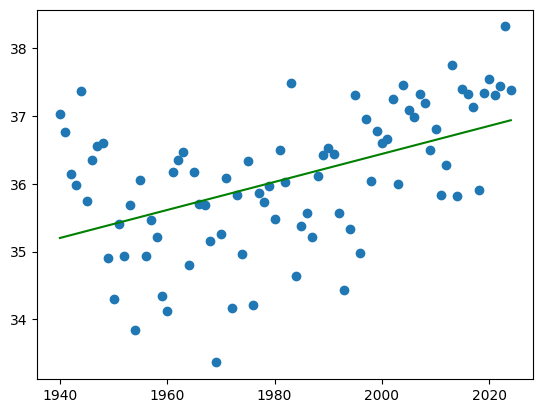

In [106]:
y_pred = model_kazakhstan.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, color="green")

In [107]:
print("intercept",model_kazakhstan.intercept_)
print("coef",model_kazakhstan.coef_[0])

intercept -4.894197823086557
coef 0.020667635905378155


intercept -3.6939735824105
coef 0.020094658935671597


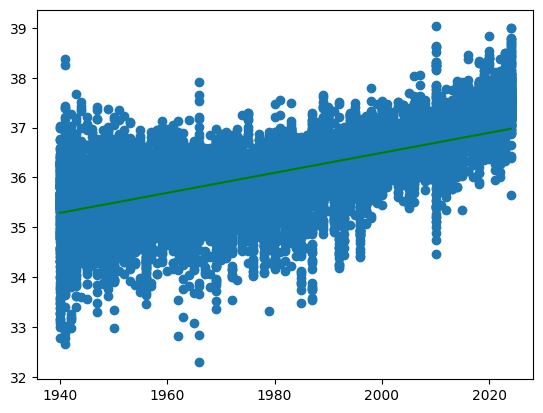

In [108]:
X = temp.Year.values.reshape(-1,1)
y = temp["Temperature anomaly"].values +36.6


model_all = LinearRegression()
model_all.fit(X,y)

y_pred = model_all.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, color="green")

print("intercept",model_all.intercept_)
print("coef",model_all.coef_[0])

In [ ]:
temp

,Entity,Code,Year,Temperature anomaly
0,Afghanistan,AFG,1940,-1.202316
1,Afghanistan,AFG,1941,0.794745
2,Afghanistan,AFG,1942,0.355437
3,Afghanistan,AFG,1943,-1.005242
4,Afghanistan,AFG,1944,-0.386346
...,...,...,...,...
18100,Zimbabwe,ZWE,2020,0.229293
18101,Zimbabwe,ZWE,2021,0.016838
18102,Zimbabwe,ZWE,2022,0.035659
18103,Zimbabwe,ZWE,2023,0.792851
